<a href="https://colab.research.google.com/github/Asaf21S/flow-matching-as-a-layer/blob/main/notebooks/classifiers_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cloning repo

In [1]:
!git clone https://github.com/Asaf21S/flow-matching-as-a-layer.git
%cd flow-matching-as-a-layer

Cloning into 'flow-matching-as-a-layer'...
remote: Enumerating objects: 78, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 78 (delta 21), reused 66 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (78/78), 39.70 KiB | 606.00 KiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/flow-matching-as-a-layer


In [2]:
%cd /content/flow-matching-as-a-layer
!git pull --ff-only

/content/flow-matching-as-a-layer
Already up to date.


# Install missing dependencies

In [3]:
!pip install -q -r requirements-colab.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


# Imports

In [4]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path("/content/flow-matching-as-a-layer")
DATA_ROOT = Path("/content/data")
FEATURE_ROOT = Path("/content/features")
RESULTS_ROOT = Path("/content/results")

for path in (DATA_ROOT, FEATURE_ROOT, RESULTS_ROOT):
    path.mkdir(parents=True, exist_ok=True)

os.environ["FMLAYER_DATA_ROOT"] = str(DATA_ROOT)
os.environ["FMLAYER_FEATURE_ROOT"] = str(FEATURE_ROOT)
os.environ["FMLAYER_RESULTS_ROOT"] = str(RESULTS_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import torch

print("torch", torch.__version__, "| cuda:", torch.cuda.is_available())

torch 2.11.0+cu128 | cuda: True


# Download datasets

In [5]:
from src.fmlayer.data.prepare import prepare_datasets

report = prepare_datasets()  # took ~3 minutes

Data root: /content/data

=== FGVC-Aircraft (aircraft) ===
    protocol: {'annotation_level': 'variant'}, approx. 2750 MB


100%|██████████| 2.75G/2.75G [01:48<00:00, 25.4MB/s]


    [ok] train   3334 images, 100 classes, 33-34 per class
    [ok] val     3333 images, 100 classes, 33-34 per class
    [ok] test    3333 images, 100 classes, 33-34 per class
    prompt: 'a photo of a 707-320 aircraft' ... 'a photo of a Yak-42 aircraft'
=== DTD (dtd) ===
    protocol: {'partition': 1}, approx. 625 MB


100%|██████████| 625M/625M [00:28<00:00, 22.0MB/s]


    [ok] train   1880 images, 47 classes, 40-40 per class
    [ok] val     1880 images, 47 classes, 40-40 per class
    [ok] test    1880 images, 47 classes, 40-40 per class
    prompt: 'a photo of a banded texture' ... 'a photo of a zigzagged texture'


In [6]:
for key, info in report["datasets"].items():
    print(f"\n{info['display_name']}  ({info['num_classes']} classes)")
    print(" ", info["class_names"][:5], "...")
    print(" ", info["prompts"][0])


FGVC-Aircraft  (100 classes)
  ['707-320', '727-200', '737-200', '737-300', '737-400'] ...
  a photo of a 707-320 aircraft

DTD  (47 classes)
  ['banded', 'blotchy', 'braided', 'bubbly', 'bumpy'] ...
  a photo of a banded texture


# Test frozen encoders

In [7]:
from src.fmlayer.encoders.check import smoke_test_encoders

encoder_report = smoke_test_encoders()

Device: cuda

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


[ok] resnet18       input (3, 224, 224) -> features (2, 512)
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


...

[ok] dinov2_vits14  input (3, 224, 224) -> features (2, 384)


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  408MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[ok] clip_rn50      input (3, 224, 224) -> features (2, 1024)
                    text prompts -> (2, 1024)


In [8]:
from src.fmlayer.encoders.registry import build_encoder

encoder = build_encoder("resnet18")
print(encoder.name, encoder.embed_dim, encoder.device)

resnet18 512 cuda


# Extract and cache features

In [9]:
from src.fmlayer.features.extract import extract_all

paths = extract_all()  # took ~8 minutes

Device: cuda

=== resnet18 ===


resnet18/dtd/train:   0%|          | 0/30 [00:00<?, ?it/s]

    [ok]     resnet18/dtd/train -> (1880, 512) dtd_train.npz


resnet18/dtd/val:   0%|          | 0/30 [00:00<?, ?it/s]

    [ok]     resnet18/dtd/val -> (1880, 512) dtd_val.npz


...

    [ok]     clip_rn50/aircraft/train -> (3334, 1024) aircraft_train.npz


clip_rn50/aircraft/val:   0%|          | 0/53 [00:00<?, ?it/s]

    [ok]     clip_rn50/aircraft/val -> (3333, 1024) aircraft_val.npz


clip_rn50/aircraft/test:   0%|          | 0/53 [00:00<?, ?it/s]

    [ok]     clip_rn50/aircraft/test -> (3333, 1024) aircraft_test.npz
    [ok]     clip_rn50/aircraft/text -> (100, 1024) aircraft_text.npz

17 feature files ready.


In [10]:
from src.fmlayer.features.cache import load_split

features, labels, meta = load_split("resnet18", "dtd", "train")
print(features.shape, labels.shape, meta["embed_dim"], len(meta["class_names"]))

text_features, _, text_meta = load_split("clip_rn50", "dtd")   # split=None -> text prototypes
print(text_features.shape, text_meta["prompts"][0])

(1880, 512) (1880,) 512 47
(47, 1024) a photo of a banded texture


# Zero-shot CLIP baseline

In [11]:
from src.fmlayer.models.zeroshot import run_zeroshot_all

zeroshot = run_zeroshot_all()  # took ~40 seconds

[FGVC-Aircraft] zero-shot CLIP RN50: 0.1545 top-1 on 3333 test images
    prompt example: 'a photo of a 707-320 aircraft'
[DTD] zero-shot CLIP RN50: 0.4005 top-1 on 1880 test images
    prompt example: 'a photo of a banded texture'


In [12]:
from src.fmlayer.utils.results import load_runs, runs_csv_path

print(runs_csv_path())
for row in load_runs():
    print(row["method"], row["dataset"], row["encoder"], f"{float(row['accuracy']):.4f}")

/content/results/runs.csv
clip_zeroshot aircraft clip_rn50 0.1545
clip_zeroshot dtd clip_rn50 0.4005


# Build the k-shot subsets

In [13]:
from src.fmlayer.data.fewshot import build_all_subsets

sizes = build_all_subsets()


=== dtd (1880 training images, 47 classes) ===
    k=5    seed=0    235 images, 5-5 per class
    k=5    seed=1    235 images, 5-5 per class
    k=5    seed=2    235 images, 5-5 per class
    k=10   seed=0    470 images, 10-10 per class
    k=10   seed=1    470 images, 10-10 per class
    k=10   seed=2    470 images, 10-10 per class
    k=full seed=0   1880 images, 40-40 per class

=== aircraft (3334 training images, 100 classes) ===
    k=5    seed=0    500 images, 5-5 per class
    k=5    seed=1    500 images, 5-5 per class
    k=5    seed=2    500 images, 5-5 per class
    k=10   seed=0   1000 images, 10-10 per class
    k=10   seed=1   1000 images, 10-10 per class
    k=10   seed=2   1000 images, 10-10 per class
    k=full seed=0   3334 images, 33-34 per class


In [14]:
from src.fmlayer.data.fewshot import load_train_subset

features, labels, indices = load_train_subset("resnet18", "dtd", 10, seed=0)
print(features.shape, labels.shape, indices[:10])

(470, 512) (470,) [ 0  1  2  6  9 10 16 20 26 32]


# Linear probe

In [15]:
from src.fmlayer.train.train_linear import run_all_linear_probes, summarize_linear_probes

probe_results = run_all_linear_probes()  # took ~2 minutes
summary = summarize_linear_probes(probe_results)

Device: cuda


linear probes:   0%|          | 0/27 [00:00<?, ?it/s]

    resnet18       dtd       k=5    seed=0  train=  235  val=0.4489@125  test=0.4628
    resnet18       dtd       k=5    seed=1  train=  235  val=0.4553@31   test=0.4420
    resnet18       dtd       k=5    seed=2  train=  235  val=0.4309@150  test=0.4495
    resnet18       dtd       k=10   seed=0  train=  470  val=0.5074@32   test=0.5399
    resnet18       dtd       k=10   seed=1  train=  470  val=0.5383@65   test=0.5383
    resnet18       dtd       k=10   seed=2  train=  470  val=0.5144@27   test=0.5553
    resnet18       dtd       k=full seed=0  train= 1880  val=0.6085@23   test=0.6335
    resnet18       dtd       k=full seed=1  train= 1880  val=0.6064@16   test=0.6255
    resnet18       dtd       k=full seed=2  train= 1880  val=0.6064@18   test=0.6261
    resnet18       aircraft  k=5    seed=0  train=  500  val=0.1869@75   test=0.1794
    resnet18       aircraft  k=5    seed=1  train=  500  val=0.2055@182  test=0.2010
    resnet18       aircraft  k=5    seed=2  train=  500  val=0.20

# Report


=== FGVC-Aircraft ===
  clip_zeroshot  clip_rn50      K=none  0.1545 +/- 0.0000  (n=1)
  linear_probe   resnet18       K=10    0.2720 +/- 0.0056  (n=3)
  linear_probe   resnet18       K=5     0.1972 +/- 0.0162  (n=3)
  linear_probe   resnet18       K=full  0.3662 +/- 0.0027  (n=3)

=== DTD ===
  clip_zeroshot  clip_rn50      K=none  0.4005 +/- 0.0000  (n=1)
  linear_probe   dinov2_vits14  K=10    0.6952 +/- 0.0074  (n=3)
  linear_probe   dinov2_vits14  K=5     0.6234 +/- 0.0014  (n=3)
  linear_probe   dinov2_vits14  K=full  0.7637 +/- 0.0083  (n=3)
  linear_probe   resnet18       K=10    0.5445 +/- 0.0094  (n=3)
  linear_probe   resnet18       K=5     0.4514 +/- 0.0105  (n=3)
  linear_probe   resnet18       K=full  0.6284 +/- 0.0045  (n=3)

Accuracy table -> /content/results/accuracy_table.csv


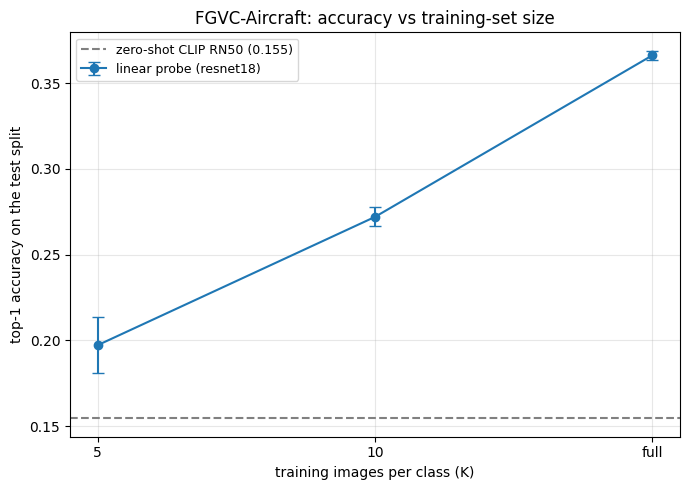

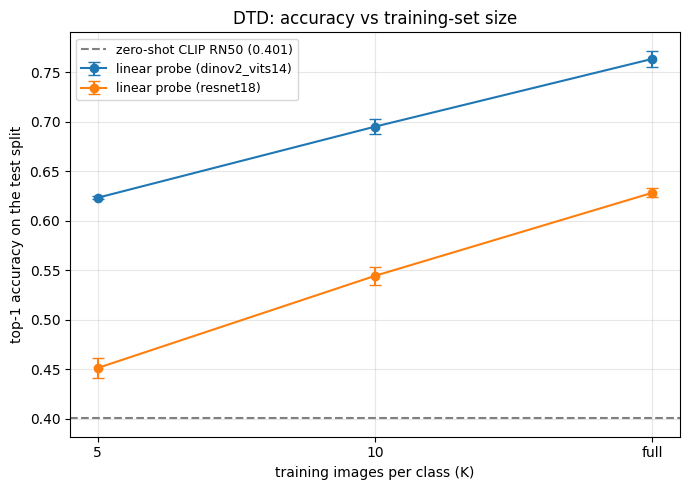

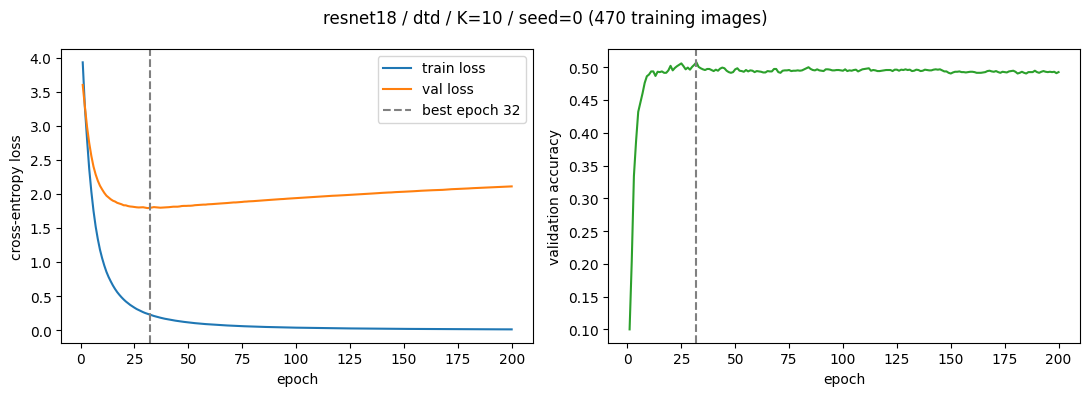

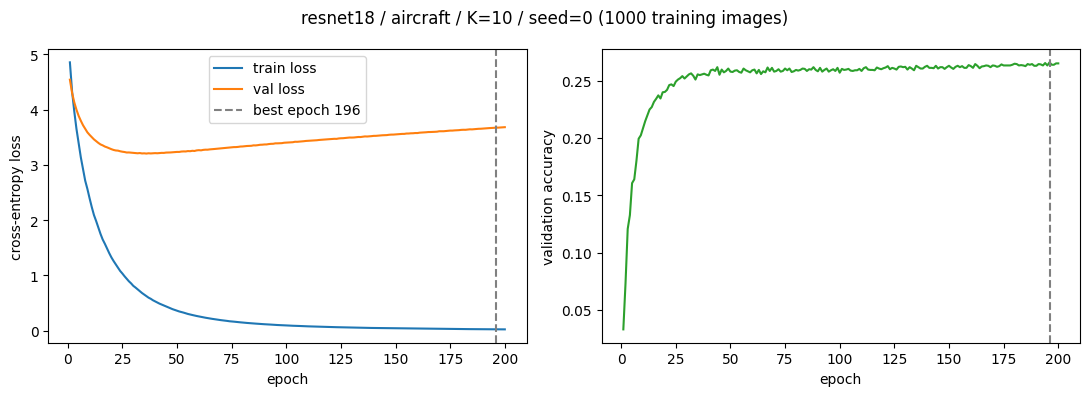

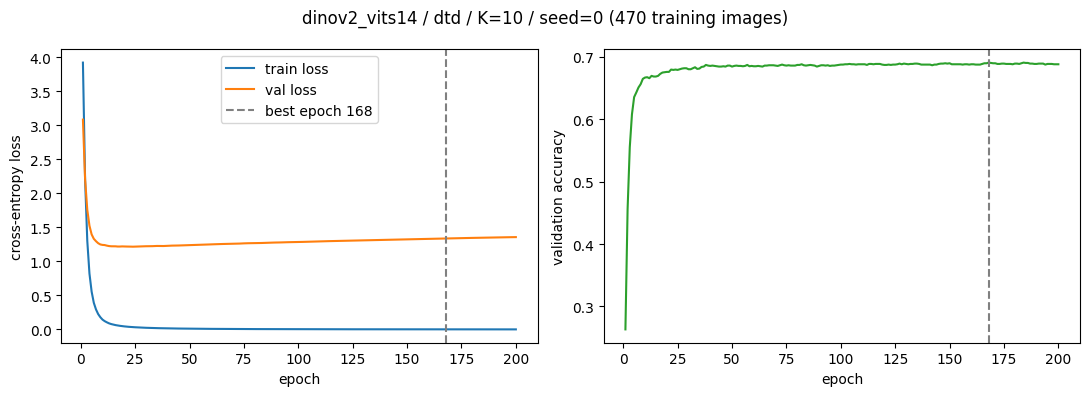

[FGVC-Aircraft] zero-shot CLIP RN50: 0.1545 top-1 on 3333 test images
    prompt example: 'a photo of a 707-320 aircraft'


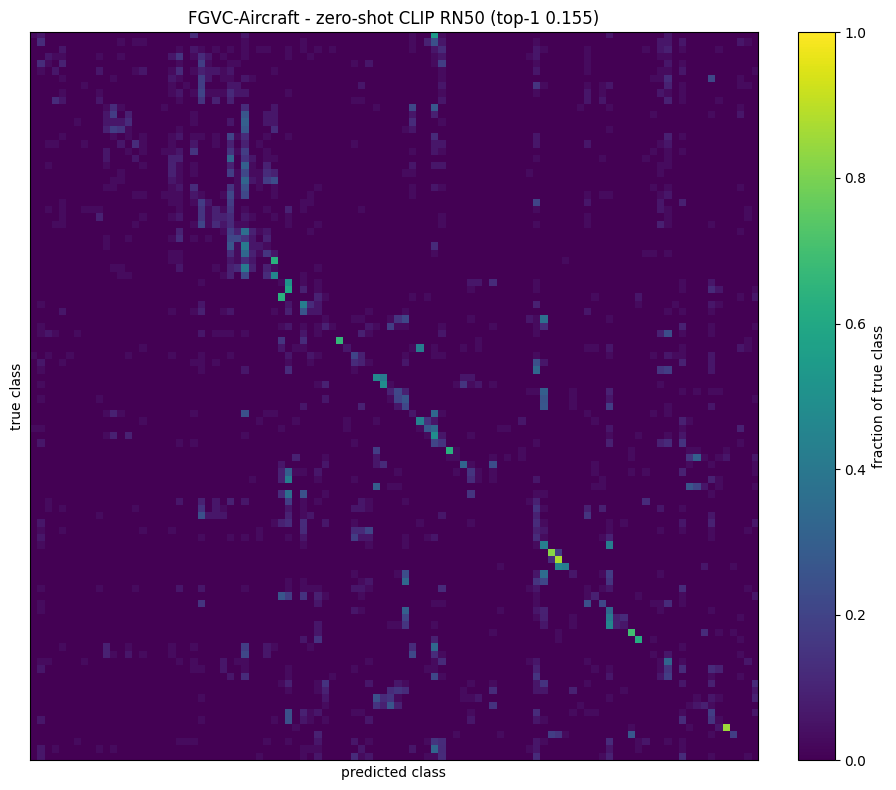

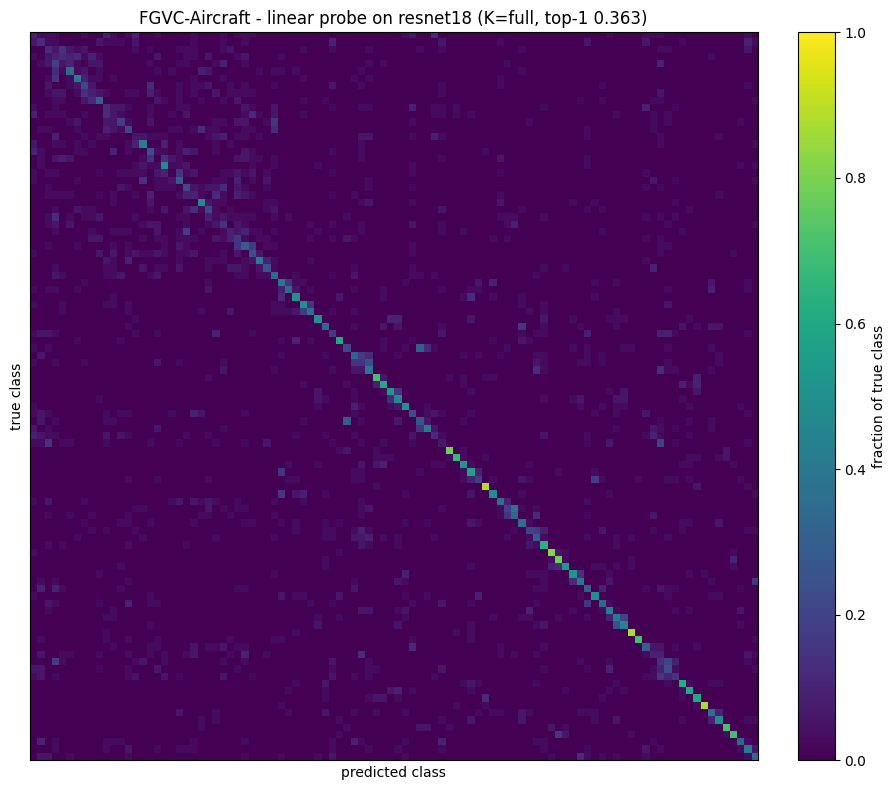

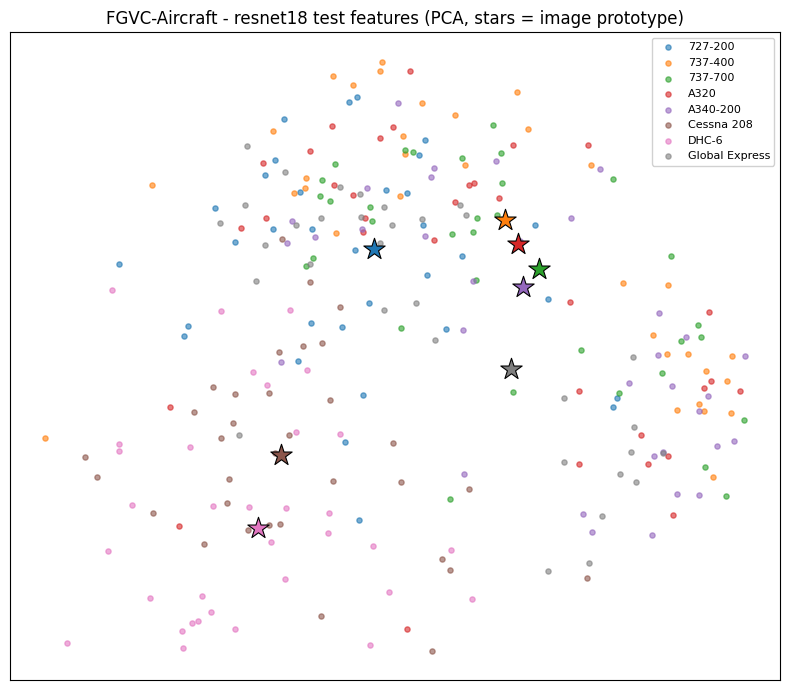

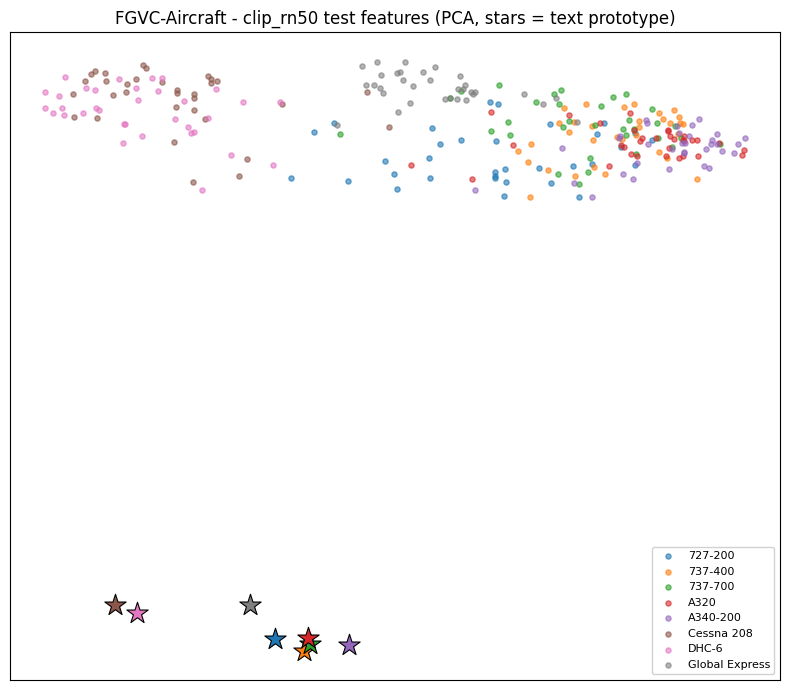

[DTD] zero-shot CLIP RN50: 0.4005 top-1 on 1880 test images
    prompt example: 'a photo of a banded texture'


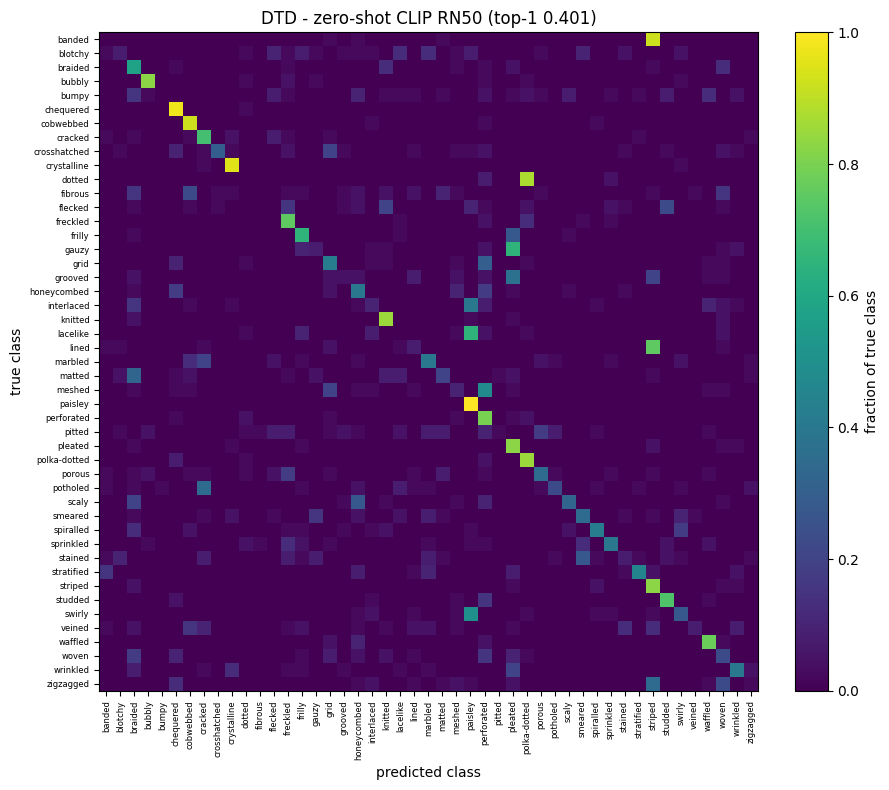

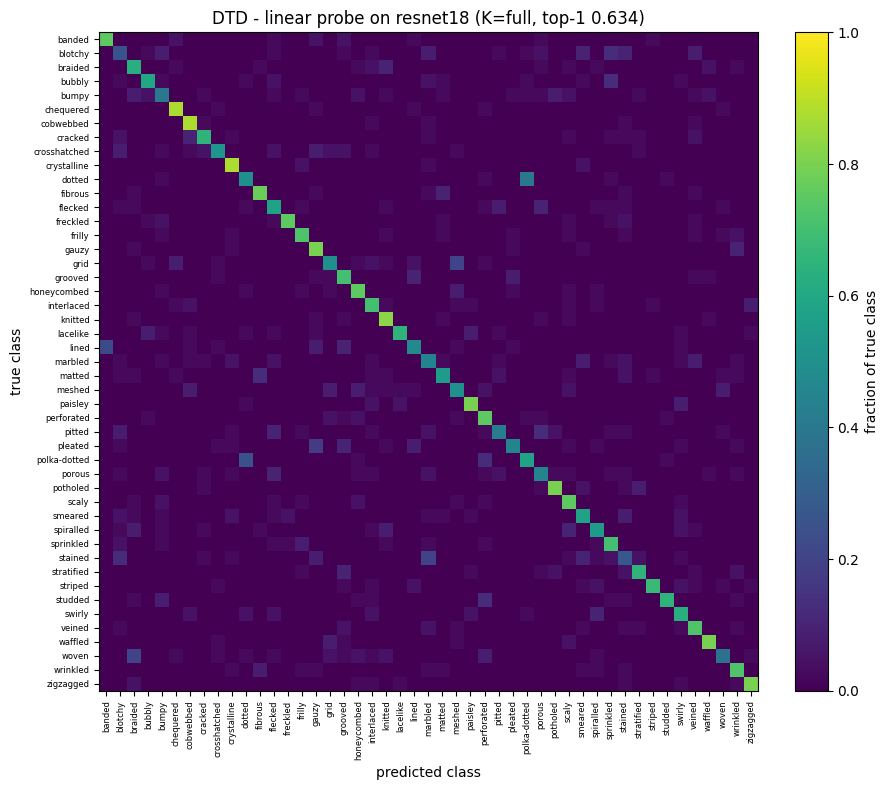

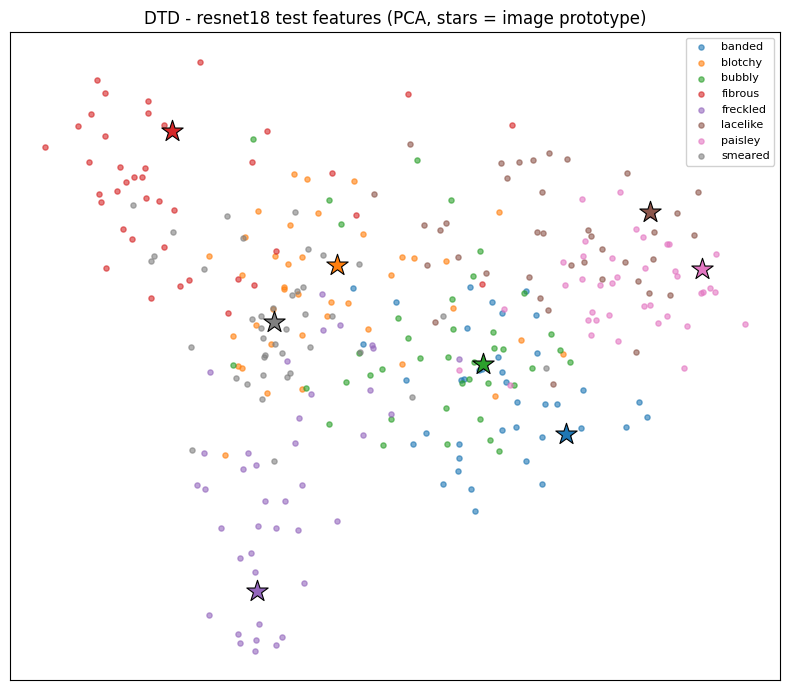

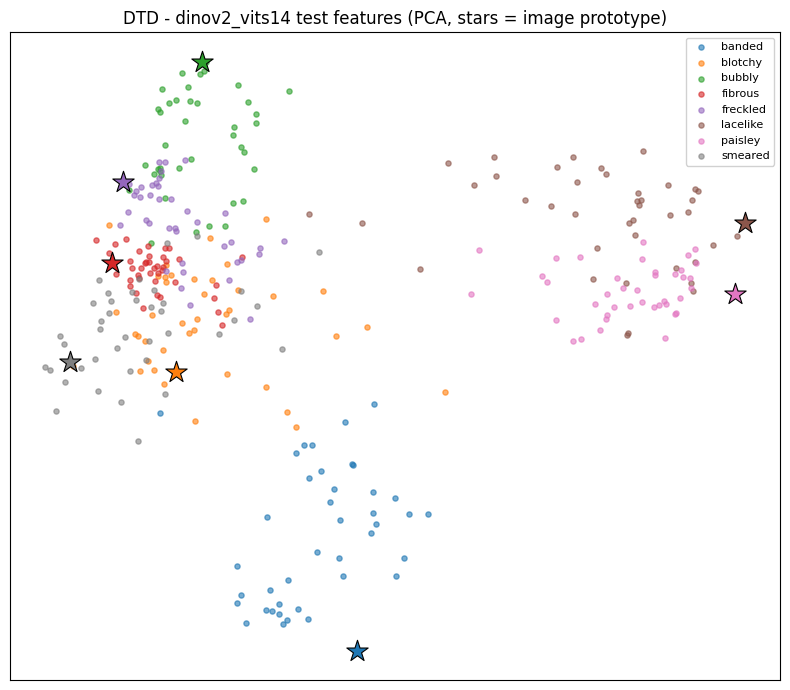

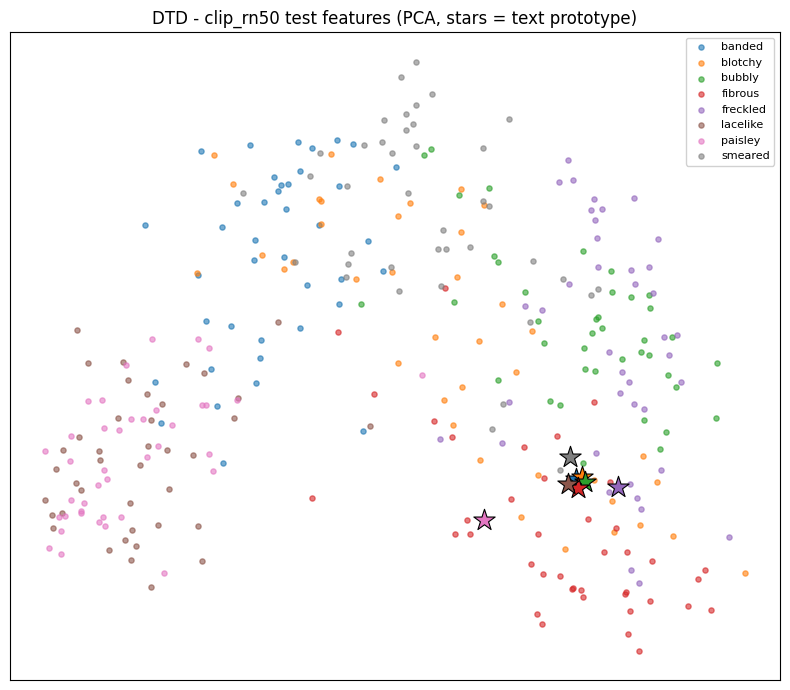

In [16]:
from src.fmlayer.report import make_report

report = make_report()  # took ~50 seconds

# Cache features and results to drive

In [17]:
from google.colab import drive

drive.mount("/content/drive")
FEATURE_ROOT = Path("/content/drive/MyDrive/fmlayer/features")
RESULTS_ROOT = Path("/content/drive/MyDrive/fmlayer/results")
for path in (FEATURE_ROOT, RESULTS_ROOT):
    path.mkdir(parents=True, exist_ok=True)

os.environ["FMLAYER_FEATURE_ROOT"] = str(FEATURE_ROOT)
os.environ["FMLAYER_RESULTS_ROOT"] = str(RESULTS_ROOT)

Mounted at /content/drive
